# Data analysis in Astronomy 

### Homework 3 due 11/18 11:59 pm

### Name: Cheng-An, Hsieh

In [40]:
import numpy as np
import astropy.io.fits as pf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as ss

"""This code use Github Copilot to help me to fix the detail problems and comment"""

'This code use Github Copilot to help me to fix the detail problems and comment'

### 1. A few weeks ago, you have learned how to do simple cross-correlation measurements. 
### Now extend your code to calculate mean($\delta y$) (mean(y_x)-mean(y_0)) when x = 1, 2, 3, 4. Estimate the uncertainty with bootstrap. 
### To do: 
### a. Estimate the uncertainty with the error of the mean and propagate the uncertainty. Compare the estimated uncertainty based on the error propagation and bootstrapping. (5 points) 
### b. Produce a plot with xaxis showing x=[1,2,3,4], and with yaxis showing the corresponding delta y values. (Please include the uncertainty) (5 points)

you can find the data at https://www.dropbox.com/s/ak159coklf1eplf/simple_correlation_10000_x_y_01234.npy?dl=0
### c. Do the linear regression with a model, delta y= a x, and get the best fit a parameter value. Plot your best-fit model in the figure. (15 points) 

### -----------------------------------------------------------------------------------------------------------------

In [44]:
### a. Estimate the uncertainty with the error of the mean and propagate the uncertainty. 
# Compare the estimated uncertainty based on the error propagation and bootstrapping. (5 points) 

def bootstrap(x, y, n  = 1000):
    
    errors = []
    n_bootstrap = n
    n_point = min(len(x), len(y))
    for _ in range(n_bootstrap):
        indices = np.random.randint(0, n_point, n_point)
        sample_x = x[indices]
        sample_y = y[indices]
        mean_diff = np.mean(sample_y) - np.mean(sample_x)
        errors.append(mean_diff)
    bootstrap_error = np.std(errors)
    return bootstrap_error

# Load the data
data = np.array(np.load('simple_correlation_10000_x_y_01234.npy'))

x = data[0]
y = data[1] 

# Calculate mean(Δy) for x = 1, 2, 3, 4 and estimate uncertainty with bootstrap
mean_dy_values = []
bootstrap_errors = []

for i in range(1, 5):
    y_x = y[x == i]
    y_0 = y[x == 0]

    if len(y_x) > 0 and len(y_0) > 0:
        mean_y_x = np.mean(y_x)
        mean_y_0 = np.mean(y_0)
        
        mean_dy = mean_y_x - mean_y_0
        mean_dy_values.append(mean_dy)
        
        # Bootstrap uncertainty for Δy
        bootstrap_error_dy = bootstrap(y_x, y_0)
        bootstrap_errors.append(bootstrap_error_dy)

        # Print mean(Δy) and bootstrap uncertainty
        print(f"x = {i}")
        print(f'Δy = ', round(mean_dy, 2))
        print(f'Bootstrap uncertainty = ', round(bootstrap_error_dy,2))



x = 1
Δy =  0.86
Bootstrap uncertainty =  0.32
x = 2
Δy =  1.99
Bootstrap uncertainty =  0.33
x = 3
Δy =  2.77
Bootstrap uncertainty =  0.32
x = 4
Δy =  4.27
Bootstrap uncertainty =  0.33


<class 'list'> <class 'list'>


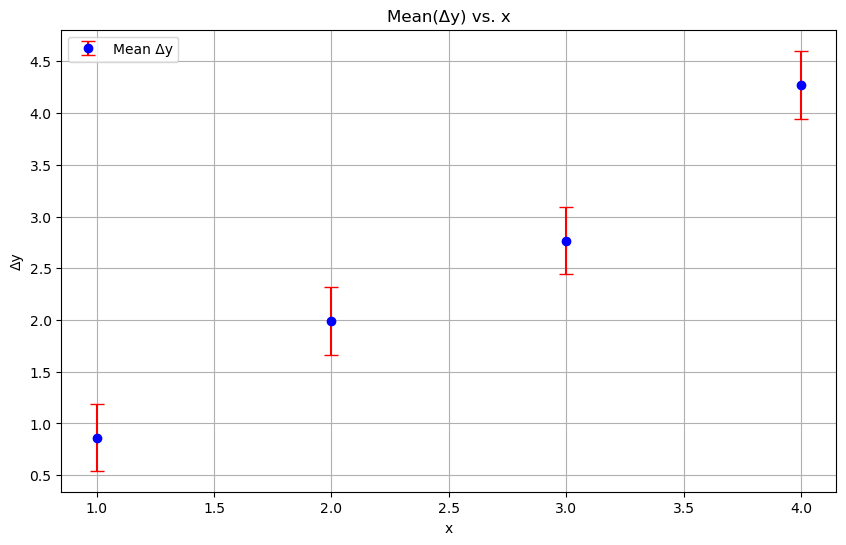

In [45]:


np.array(mean_dy_values)
np.array(bootstrap_errors)
x_values = [1, 2, 3, 4]
np.array(x_values)

print(type(mean_dy_values), type(bootstrap_errors))


plt.figure(figsize=(10, 6))

def plot(x_values, mean_dy_values, bootstrap_errors):
    plt.errorbar(
        x_values,
        mean_dy_values,
        yerr=bootstrap_errors,
        fmt='o',
        color='blue',
        ecolor='red',
        capsize=5,
        label='Mean Δy'
    )

    plt.xlabel('x')
    plt.ylabel('Δy')
    plt.title('Mean(Δy) vs. x')
    plt.grid(True)
    plt.legend()
    
plot(x_values, mean_dy_values, bootstrap_errors)
plt.show()

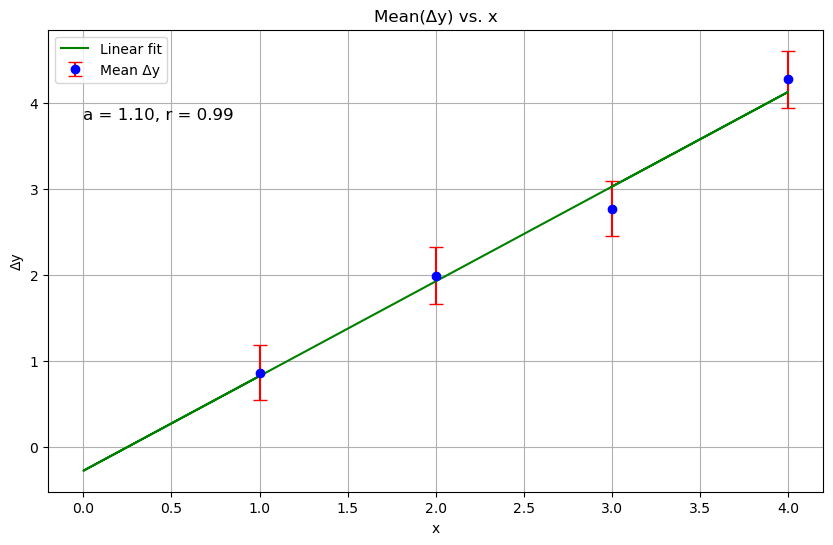

In [46]:
### c. Do the linear regression with a model, delta y= a x, and get the best fit a parameter value.
#  Plot your best-fit model in the figure. (15 points) 

# Linear regression
slope, intercept, r_value, p_value, std_err = ss.linregress(x_values, mean_dy_values)

plt.figure(figsize=(10, 6))

plot(x_values, mean_dy_values, bootstrap_errors)

plt.plot(
    x,
    slope * x + intercept,
    color='green',
    label='Linear fit'
)

plt.text(0, 3.8, f'a = {slope:.2f}, r = {r_value:.2f}', fontsize=12, color='black')

plt.legend()
plt.show()

### 2. Finish fitting the black body spectrum


### To do:

### Finish writing the blackbody model and get the best-fit temperature and uncertainty of the spectrum. (10 points) 

In [20]:
# https://www.dropbox.com/s/c8qomgjpbvlj87o/hubble_original_data.fits?dl=0

In [47]:
black_body = pf.getdata('spec-3744-55209-0386.fits',1)
# https://www.dropbox.com/s/n2xrychdkulsqjp/spec-3744-55209-0386.fits?dl=0

In [48]:
search = np.where(black_body['ivar']>0)

In [49]:
flux = black_body['flux'][search[0]].astype('float64')
wavelength = 10**black_body['loglam'][search[0]].astype('float64')
ivar = black_body['ivar'][search[0]].astype('float64')

Text(0, 0.5, 'Flux')

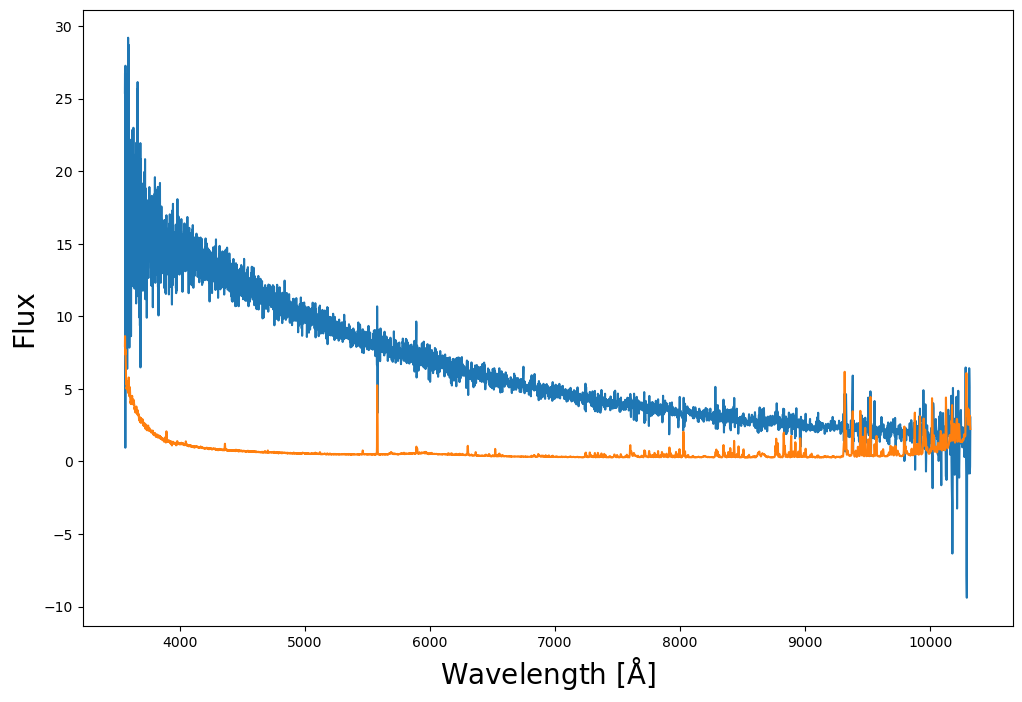

In [50]:
plt.figure(figsize=(12,8))
plt.plot(wavelength,flux)
plt.plot(wavelength,1./np.sqrt(ivar))
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux',fontsize=20)

In [53]:
def blackbody_SED(x, T, A):
    h, c, k = 6.626e-34, 3.0e8, 1.38e-23  # Planck constant, speed of light, Boltzmann constant
    temperature = T
    a = A
    f_lambda =   a * (2.0 * h * c**2) / (x**5 * (np.exp(h * c / (x * k * temperature)) - 1.0))
    # Write the content 
    # parameter [amplitude and temperature]
    # Let's just get the temperature right
    return f_lambda

In [54]:
def residual_function(p,data):
    x,y,y_ivar = data
    return np.sqrt(y_ivar)*(y-blackbody_SED(p,x))

wavelength_SI = wavelength * 1e-10
print(wavelength)


[ 3560.41057274  3561.22964051  3562.0508522  ... 10315.73586855
 10318.10332561 10320.48265745]


temperature:9652.28K, amplitude:4.996818402534921e-14


Text(0, 0.5, 'Flux')

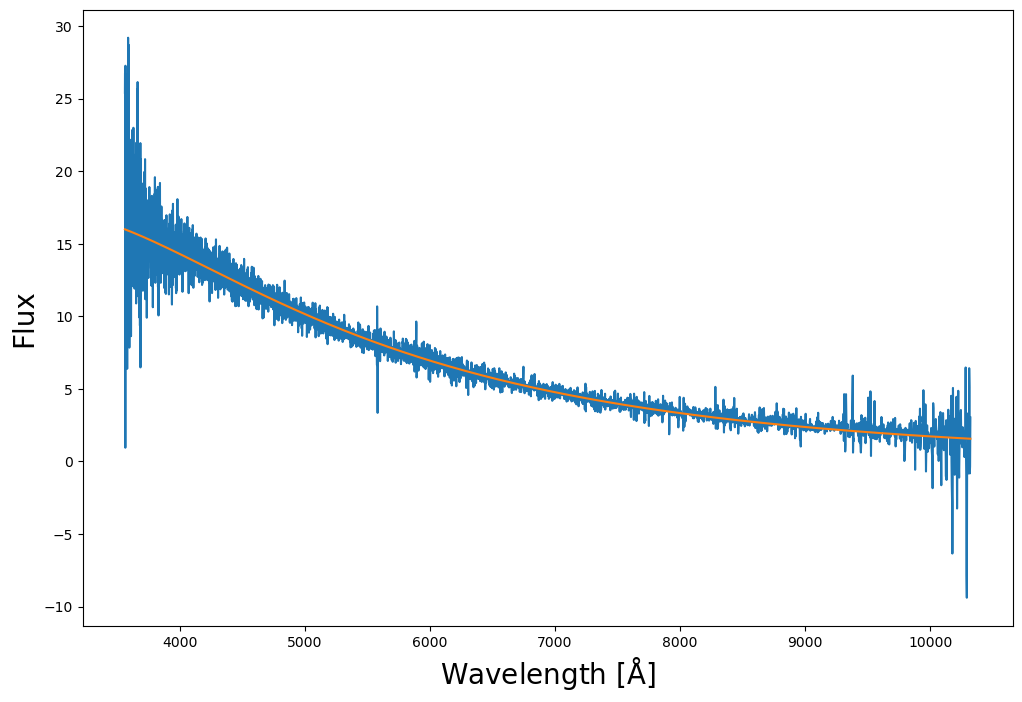

In [58]:
from scipy.optimize import curve_fit

paramsinitial =  [5000, 1]

# Perform the fit
popt, conv= curve_fit(blackbody_SED, wavelength_SI, flux, p0=paramsinitial, maxfev=20000, sigma=1./np.sqrt(ivar), absolute_sigma=True)

print(f"temperature:{round(popt[0], 2)}K, amplitude:{popt[1]}")

plt.figure(figsize=(12,8))
plt.plot(wavelength,flux)
plt.plot(wavelength,blackbody_SED(wavelength_SI,popt[0],popt[1]))
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux',fontsize=20)

### -----------------------------------------------------------------

### 3. Measuring the rest equavalent width

### The rest equivalent width (the area of flux absorbed by the gas) of an absorption line contains physical information about the abundance of the gas. Astronomers frequently need to measure the rest equivalent width of absorption lines. 

### We now have 6 absorption line spectra. The two absorption lines are MgII 2796 and 2803. Their exact wavelengths are 2796.35 and 2803.53 Angstrom. 

### The goal is to obtain the rest equivalent widths of the two absorption lines for the 6 spectra. 

### To do:

### 1. Write a function consisting of two gaussians with central wavelengths at 2796.35 and 2803.53 Angstrom and obtain the best fit parameters of the gaussians. Based on the best fit parameters, you can get the rest equivalent widths of the absorption lines and the uncertainty of the rest equivalent widths. (You need to input the error array as well when doing the fitting.) (15 points) 

### 2. Plot the best fit models with the absorption line spectra together to demonstrate that what you get is truly the best fit models. (Similar to Figure 11 in https://ui.adsabs.harvard.edu/abs/2017ApJ...850..156L/abstract) (15 points) 

You can find the data at https://www.dropbox.com/s/bp63yptckslvzd5/Simple_absorption_line_spectra.fits?dl=0

The data structure can be found below. 

In [59]:
data = pf.open('Simple_absorption_line_spectra.fits')

In [60]:
spectra = data[0].data
error = data[1].data
wavelength = data[2].data

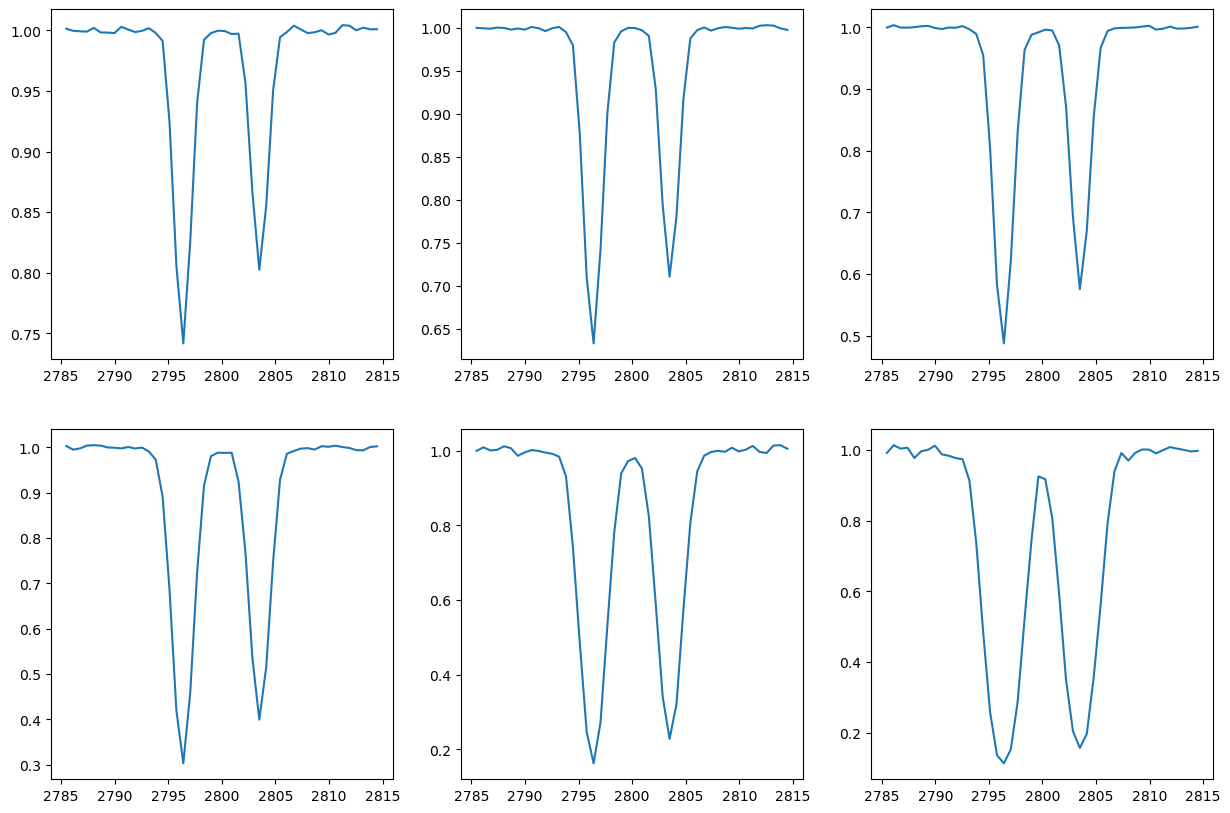

In [61]:
plt.figure(figsize=(15,10))
for i in range(0,len(spectra[:,0])):
    plt.subplot(2,3,i+1)
    plt.plot(wavelength,spectra[i,:])

In [62]:
def double_gaussian_continuum(wavelength, continuum, A1, mu1, sigma1, A2, mu2, sigma2):
    
    gaussian1 = A1 * np.exp(-0.5 * ((wavelength - mu1) / sigma1)**2)
    gaussian2 = A2 * np.exp(-0.5 * ((wavelength - mu2) / sigma2)**2)
    return continuum + gaussian1 + gaussian2

def fit_spectrum(wavelength, flux, flux_error):
   
    # Initial guesses
    continuum_init = 1.0
    A1_init = -(1 - min(flux))
    mu1_init = 2796.35
    sigma1_init = 1.0
    A2_init = -(1 - min(flux))
    mu2_init = 2803.53
    sigma2_init = 1.0

    initial_guess = [continuum_init, A1_init, mu1_init, sigma1_init, A2_init, mu2_init, sigma2_init]

    # Define bounds to ensure realistic fitting
    bounds_lower = [0.9, -np.inf, 2790, 0.5, -np.inf, 2800, 0.5]
    bounds_upper = [1.1, 0, 2800, 3.0, 0, 2810, 3.0]

    try:
        popt, pcov = curve_fit(
            double_gaussian_continuum,
            wavelength,
            flux,
            p0=initial_guess,
            sigma=flux_error,
            absolute_sigma=True,
            bounds=(bounds_lower, bounds_upper)
        )

        perr = np.sqrt(np.diag(pcov))

    except RuntimeError:
        print("Error - curve_fit failed")
        popt = [np.nan] * 7
        perr = [np.nan] * 7

    # Calculate fitted flux
    fitted_flux = double_gaussian_continuum(wavelength, *popt)

    # Extract parameters
    continuum, A1, mu1, sigma1, A2, mu2, sigma2 = popt
    continuum_err, A1_err, mu1_err, sigma1_err, A2_err, mu2_err, sigma2_err = perr

    # Calculate Equivalent Widths (EW)
    # EW = abs(A) * sigma * sqrt(2 * pi)
    ew1 = np.abs(A1) * sigma1 * np.sqrt(2 * np.pi)
    ew2 = np.abs(A2) * sigma2 * np.sqrt(2 * np.pi)

    # Propagate uncertainties
    if not np.isnan(A1_err) and not np.isnan(sigma1_err):
        ew1_err = np.sqrt( (sigma1 * np.sqrt(2 * np.pi) * A1_err)**2 +
                           (A1 * np.sqrt(2 * np.pi) * sigma1_err)**2 )
    else:
        ew1_err = np.nan
        print("nan")

    if not np.isnan(A2_err) and not np.isnan(sigma2_err):
        ew2_err = np.sqrt( (sigma2 * np.sqrt(2 * np.pi) * A2_err)**2 +
                           (A2 * np.sqrt(2 * np.pi) * sigma2_err)**2 )
    else:
        ew2_err = np.nan
        print("nan")

    ew_rest = {
        'MgII_2796_EW': (ew1, ew1_err),
        'MgII_2803_EW': (ew2, ew2_err)
    }

    return popt, perr, fitted_flux, ew_rest


Spectrum 1/6


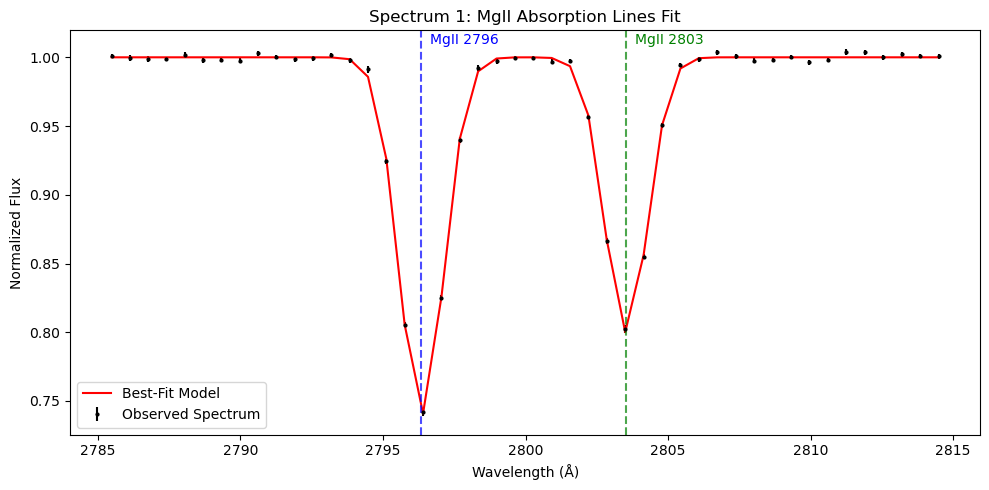

Best-Fit Parameters:
  MgII 2796 Amplitude (A1): -0.2598 ± 0.0021
  MgII 2796 Mean (mu1): 2796.3530 Å ± 0.0055 Å
  MgII 2796 Std (sigma1): 0.7796 Å ± 0.0068 Å
  MgII 2803 Amplitude (A2): -0.2002 ± 0.0022
  MgII 2803 Mean (mu2): 2803.5306 Å ± 0.0070 Å
  MgII 2803 Stddev (sigma2): 0.7518 Å ± 0.0072 Å

Rest Equivalent Widths:
  MgII_2796_EW: 0.5078 Å ± 0.0060 Å

  MgII_2803_EW: 0.3773 Å ± 0.0055 Å

Spectrum 2/6


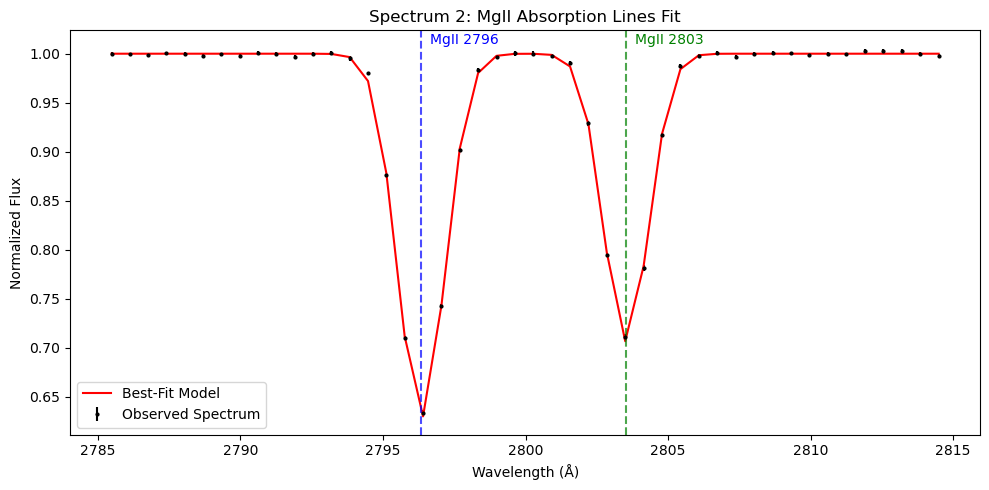

Best-Fit Parameters:
  MgII 2796 Amplitude (A1): -0.3713 ± 0.0020
  MgII 2796 Mean (mu1): 2796.3440 Å ± 0.0041 Å
  MgII 2796 Std (sigma1): 0.8222 Å ± 0.0042 Å
  MgII 2803 Amplitude (A2): -0.2938 ± 0.0023
  MgII 2803 Mean (mu2): 2803.5281 Å ± 0.0058 Å
  MgII 2803 Stddev (sigma2): 0.7880 Å ± 0.0059 Å

Rest Equivalent Widths:
  MgII_2796_EW: 0.7652 Å ± 0.0057 Å

  MgII_2803_EW: 0.5803 Å ± 0.0063 Å

Spectrum 3/6


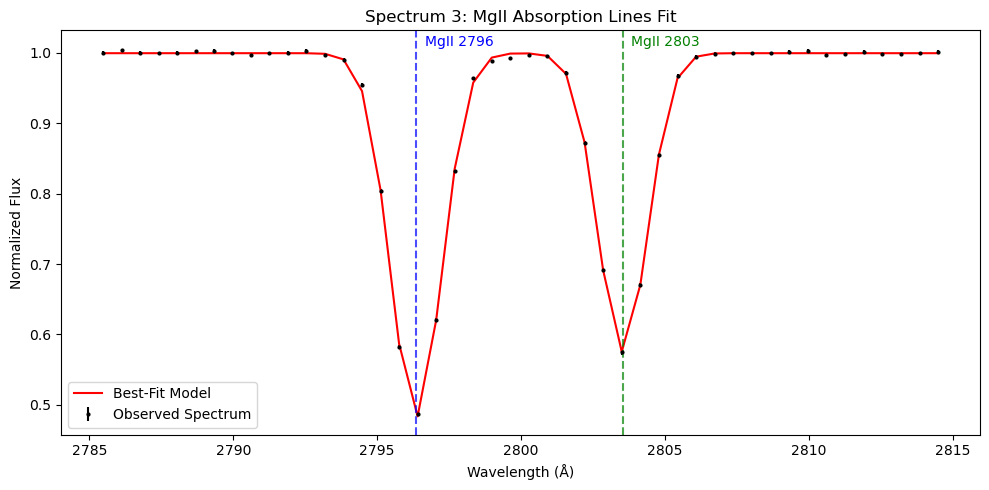

Best-Fit Parameters:
  MgII 2796 Amplitude (A1): -0.5169 ± 0.0022
  MgII 2796 Mean (mu1): 2796.3534 Å ± 0.0038 Å
  MgII 2796 Std (sigma1): 0.8841 Å ± 0.0041 Å
  MgII 2803 Amplitude (A2): -0.4246 ± 0.0029
  MgII 2803 Mean (mu2): 2803.5329 Å ± 0.0053 Å
  MgII 2803 Stddev (sigma2): 0.8535 Å ± 0.0058 Å

Rest Equivalent Widths:
  MgII_2796_EW: 1.1456 Å ± 0.0072 Å

  MgII_2803_EW: 0.9084 Å ± 0.0088 Å

Spectrum 4/6


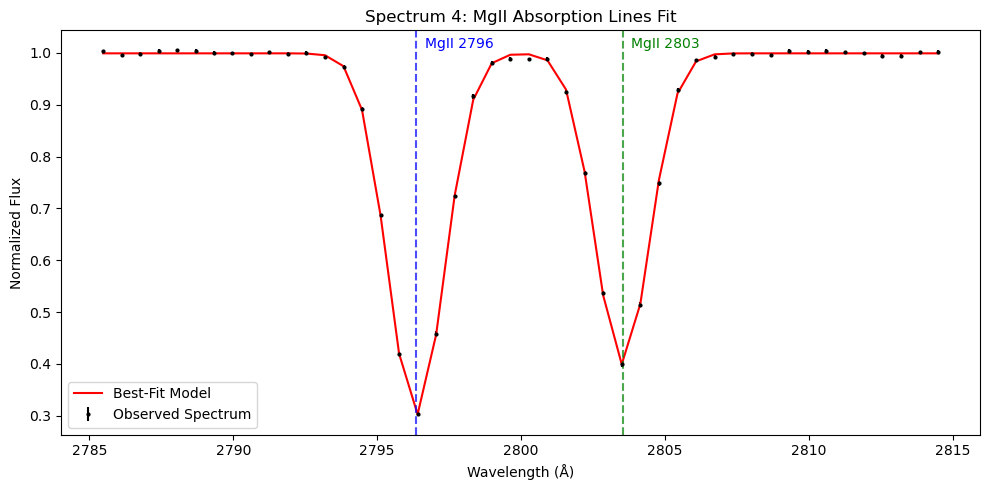

Best-Fit Parameters:
  MgII 2796 Amplitude (A1): -0.6972 ± 0.0032
  MgII 2796 Mean (mu1): 2796.3558 Å ± 0.0042 Å
  MgII 2796 Std (sigma1): 0.9779 Å ± 0.0043 Å
  MgII 2803 Amplitude (A2): -0.6000 ± 0.0038
  MgII 2803 Mean (mu2): 2803.5205 Å ± 0.0058 Å
  MgII 2803 Stddev (sigma2): 0.9451 Å ± 0.0060 Å

Rest Equivalent Widths:
  MgII_2796_EW: 1.7090 Å ± 0.0109 Å

  MgII_2803_EW: 1.4214 Å ± 0.0128 Å

Spectrum 5/6


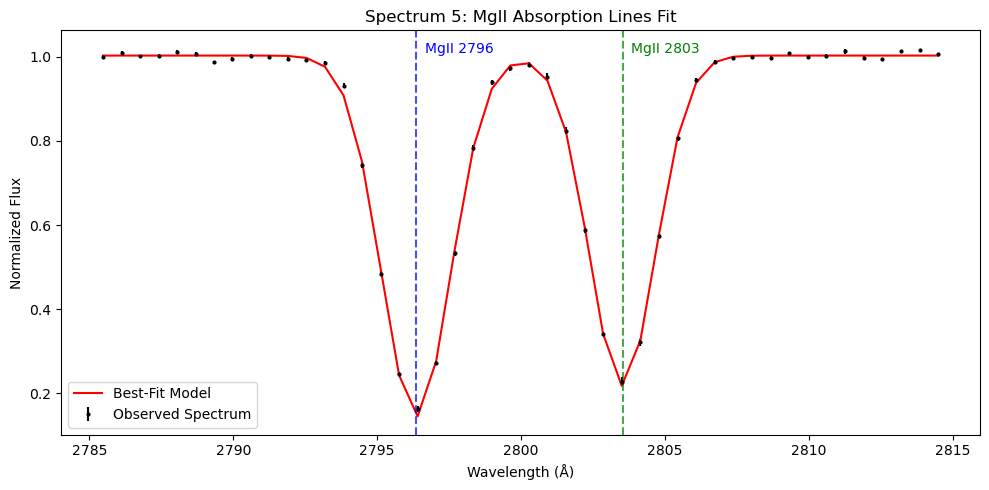

Best-Fit Parameters:
  MgII 2796 Amplitude (A1): -0.8583 ± 0.0044
  MgII 2796 Mean (mu1): 2796.3544 Å ± 0.0069 Å
  MgII 2796 Std (sigma1): 1.2017 Å ± 0.0077 Å
  MgII 2803 Amplitude (A2): -0.7851 ± 0.0055
  MgII 2803 Mean (mu2): 2803.5203 Å ± 0.0083 Å
  MgII 2803 Stddev (sigma2): 1.1456 Å ± 0.0088 Å

Rest Equivalent Widths:
  MgII_2796_EW: 2.5854 Å ± 0.0210 Å

  MgII_2803_EW: 2.2544 Å ± 0.0234 Å

Spectrum 6/6


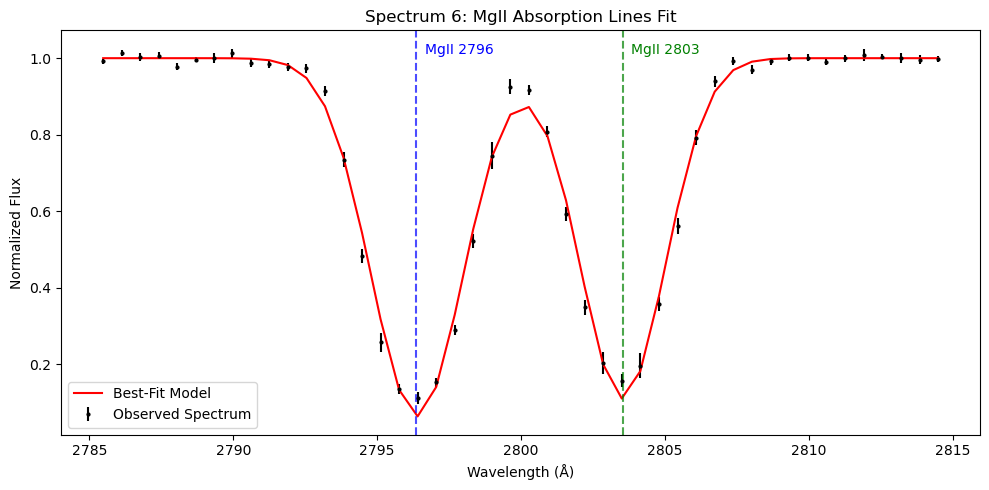

Best-Fit Parameters:
  MgII 2796 Amplitude (A1): -0.9360 ± 0.0086
  MgII 2796 Mean (mu1): 2796.3879 Å ± 0.0200 Å
  MgII 2796 Std (sigma1): 1.5973 Å ± 0.0210 Å
  MgII 2803 Amplitude (A2): -0.8894 ± 0.0128
  MgII 2803 Mean (mu2): 2803.5340 Å ± 0.0225 Å
  MgII 2803 Stddev (sigma2): 1.4823 Å ± 0.0208 Å

Rest Equivalent Widths:
  MgII_2796_EW: 3.7476 Å ± 0.0602 Å

  MgII_2803_EW: 3.3049 Å ± 0.0663 Å



In [17]:
# Convert lists to NumPy arrays
spectra = np.array(spectra)  
error = np.array(error)    


all_fit_params = []
all_fit_errors = []
all_fitted_flux = []
all_ew_rest = []

# Loop through each spectrum
for i in range(spectra.shape[0]):
    print(f"Spectrum {i+1}/{spectra.shape[0]}")

    # Extract the current spectrum and its error
    current_flux = spectra[i]
    current_error = error[i]

    # Fit the absorption lines
    popt, perr, fitted_flux, ew_rest = fit_spectrum(wavelength, current_flux, current_error)

    # Store the results
    all_fit_params.append(popt)
    all_fit_errors.append(perr)
    all_fitted_flux.append(fitted_flux)
    all_ew_rest.append(ew_rest)

### 2. Plot the best fit models with the absorption line spectra together to demonstrate that what you get is truly the best fit models. 
# (Similar to Figure 11 in https://ui.adsabs.harvard.edu/abs/2017ApJ...850..156L/abstract) (15 points) 

    # Plot the observed spectrum and the best-fit model
    plt.figure(figsize=(10, 5))
    plt.errorbar(wavelength, current_flux, yerr=current_error, fmt='k.', markersize=4, label='Observed Spectrum')
    plt.plot(wavelength, fitted_flux, 'r-', label='Best-Fit Model')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Normalized Flux')
    plt.title(f'Spectrum {i+1}: MgII Absorption Lines Fit')
    plt.legend()

    # Highlight the fitted regions
    plt.axvline(2796.35, color='blue', linestyle='--', alpha=0.7)
    plt.axvline(2803.53, color='green', linestyle='--', alpha=0.7)
    plt.text(2796.35 + 0.3, 1.01, 'MgII 2796', color='blue')
    plt.text(2803.53 + 0.3, 1.01, 'MgII 2803', color='green')

    plt.tight_layout()
    plt.show()

    # Print the fit parameters and EWs
    continuum, A1, mu1, sigma1, A2, mu2, sigma2 = popt
    continuum_err, A1_err, mu1_err, sigma1_err, A2_err, mu2_err, sigma2_err = perr

    print("Best-Fit Parameters:")
    print(f"  MgII 2796 Amplitude (A1): {A1:.4f} ± {A1_err:.4f}")
    print(f"  MgII 2796 Mean (mu1): {mu1:.4f} Å ± {mu1_err:.4f} Å")
    print(f"  MgII 2796 Std (sigma1): {sigma1:.4f} Å ± {sigma1_err:.4f} Å")
    print(f"  MgII 2803 Amplitude (A2): {A2:.4f} ± {A2_err:.4f}")
    print(f"  MgII 2803 Mean (mu2): {mu2:.4f} Å ± {mu2_err:.4f} Å")
    print(f"  MgII 2803 Stddev (sigma2): {sigma2:.4f} Å ± {sigma2_err:.4f} Å")

    print("\nRest Equivalent Widths:")
    for key, (ew, ew_err) in ew_rest.items():
        if not np.isnan(ew_err):
            print(f"  {key}: {ew:.4f} Å ± {ew_err:.4f} Å\n")
        else:
            print(f"  {key}: {ew:.4f} Å")




### -----------------------------------------------------------------------------------------------------------------

### 4. Decomposing QSO spectra with NMF
### In 11/5, we use PCA to decompose the SDSS QSO spectra. Now, we use another technique, called none-negative matrix factoriation (NMF), to do so. [Use the median-filter smooth spectra]

### TO DO:

### 1. Do the the NMF and explore the outputs! (10 points)

Follow the code above!

1. Data structure matrix [i_object, i_feature]


2. nmf = NMF(n_components=6)
   
   nmf.fit(matrix)
   
   
3. plot wavelength, nmf.components_[i] i=0,1,2,3,4,5,6 (please plot each component separately)

### 2. Please observe the NMF "eigenspectra" and describe what spectral features are captured by each component. (10 points)

### 3. Please use the NMF eigenspectra to reconstruct the observed quasar spectra and plot the first 10 observed quasar spectra (i_object<10) and the reconstructed spectra. (15 points)



In [63]:
from sklearn.decomposition import NMF
from sklearn.decomposition import PCA

data = pf.open('clean_spectra.fits')
wavelength = 10**data[2].data

import scipy.ndimage as sn
smooth_spectra = np.zeros((len(data[0].data),len(data[0].data[0])))
for i_object in range(0,len(data[0].data)):
    smooth_spectra[i_object] = sn.median_filter(data[0].data[i_object],10)




/Users/xiechengan/miniforge3/envs/myenv_x86/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


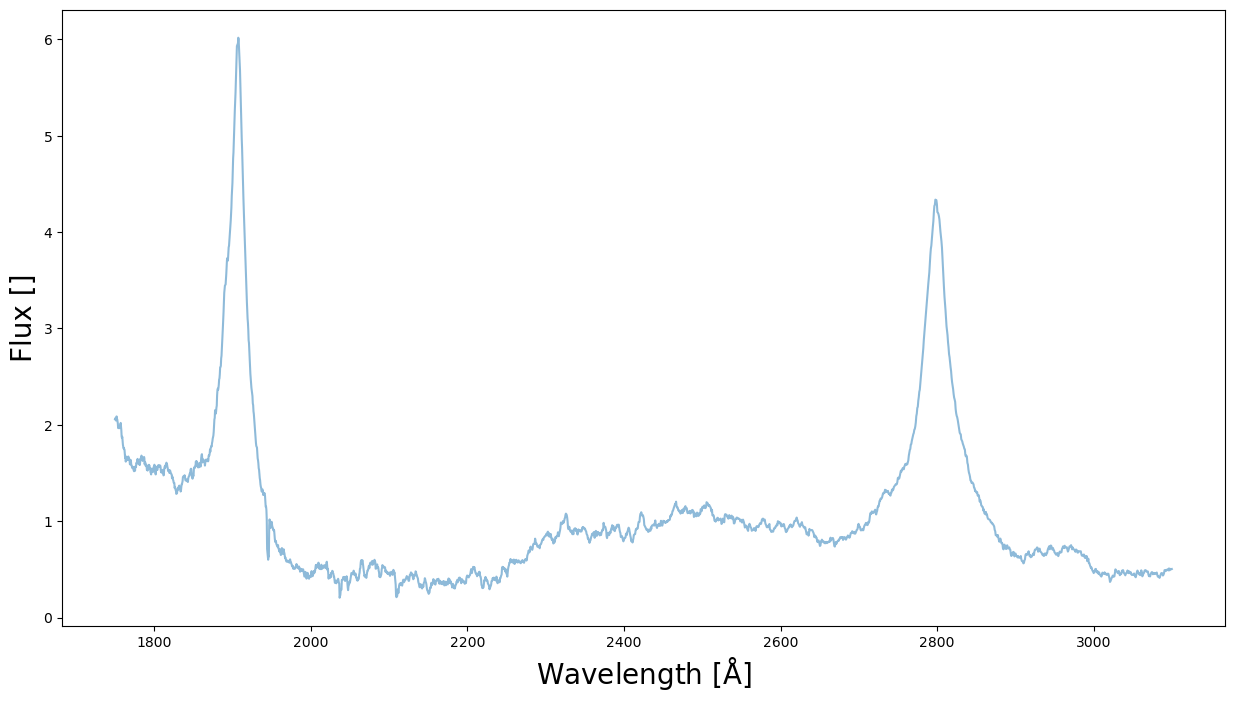

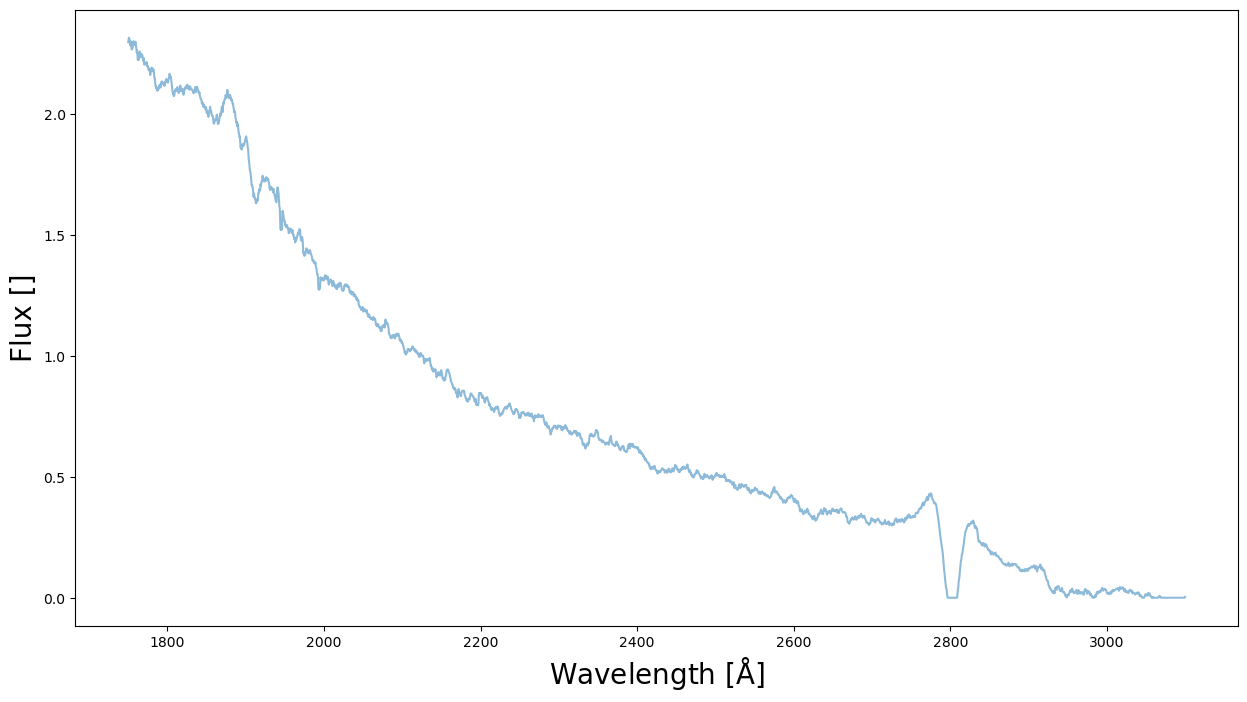

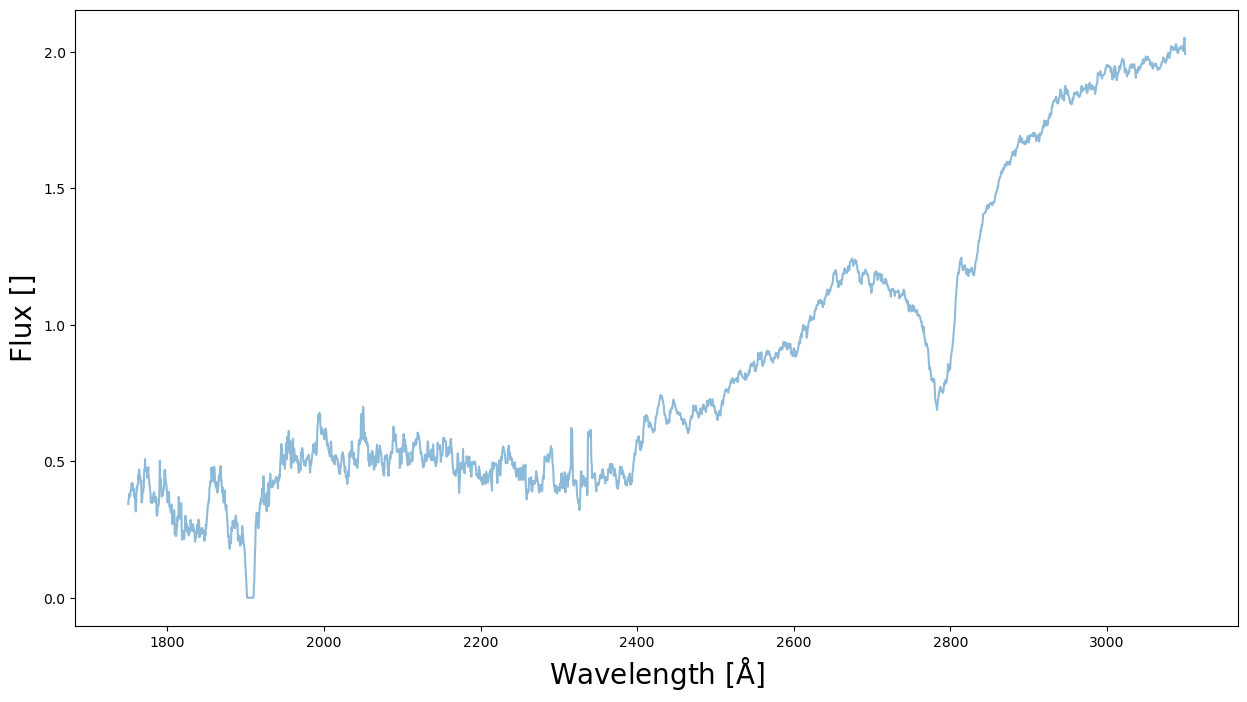

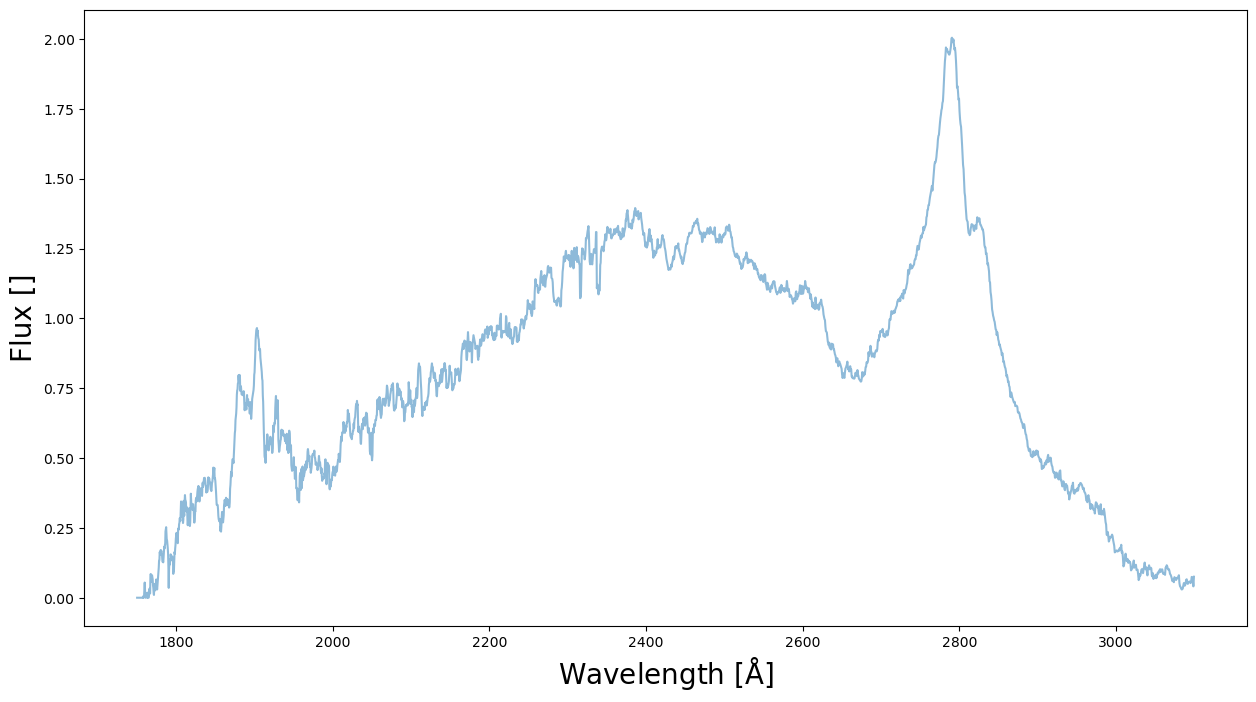

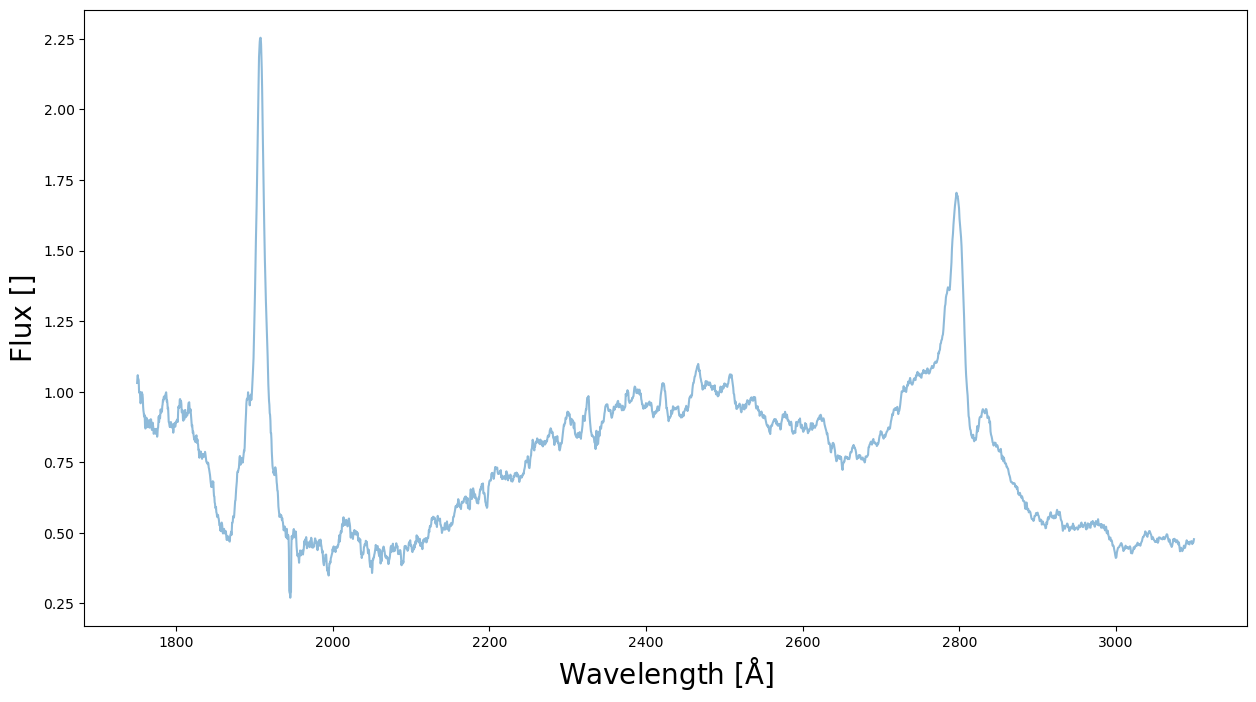

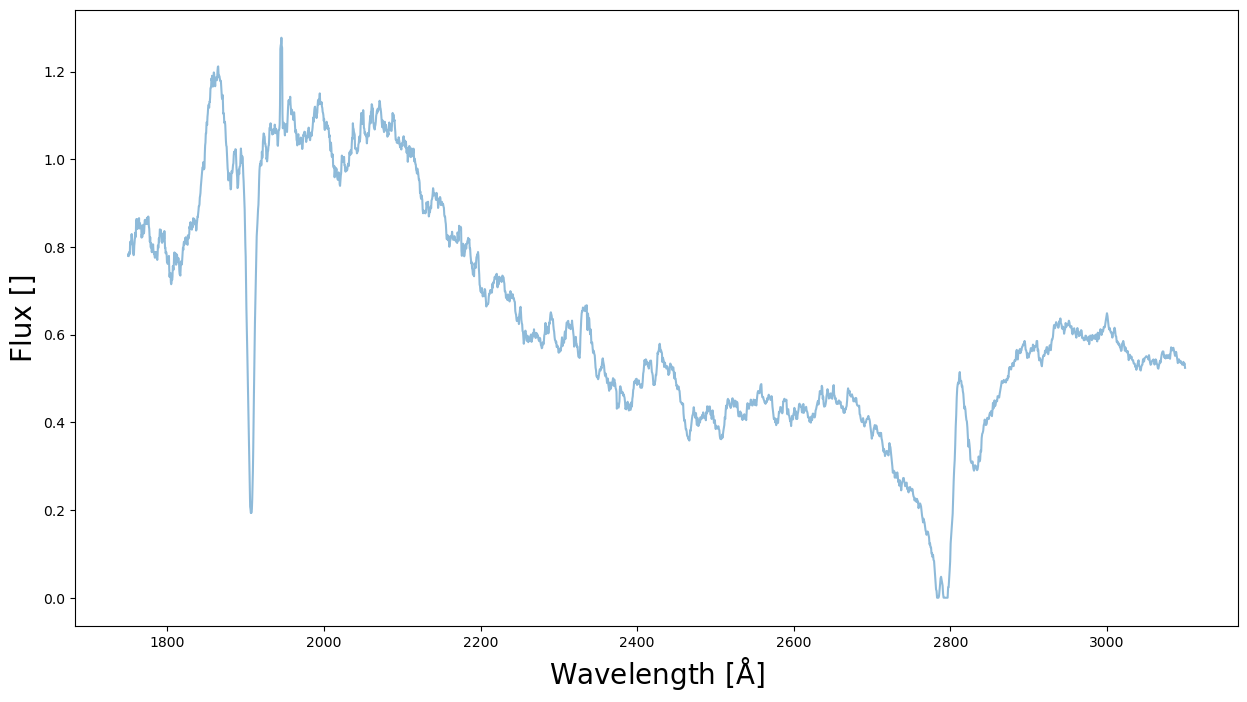

In [64]:
Data_matrix = np.maximum(smooth_spectra, 0)  # Ensure non-negative values
nmf = NMF(n_components=6)
nmf.fit(Data_matrix)


for i in range(len(nmf.components_)):
   plt.figure(figsize=(15,8))
   plt.plot(wavelength,nmf.components_[i],alpha=0.5)
   plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
   plt.ylabel('Flux []',fontsize=20)
   plt.show()


### 2. Please observe the NMF "eigenspectra" and describe what spectral features are captured by each component. (10 points)

- the first eigenspectra show the mean and have two significant peaks at ~1900A and ~2800A.
- the second eigenspectra show a genaral decline trend for the spectra, also have a small valley at 2800A.
- the third eigenspectra show a increasing trend, a small valley at 1900A and large valley at 2800A.
- the fourth eigenspectra show a significant valley before 2800A, it means some spectra have the feature.
- the fifth eigenspectra show also two peak, but the other part have different trend with mean spectra, maybe it shows the strength for spectra.
- the sixth spectra show two significant valleys, maybe it is for the ratio of peak and valley at 1900A and 2800A.





/Users/xiechengan/miniforge3/envs/myenv_x86/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


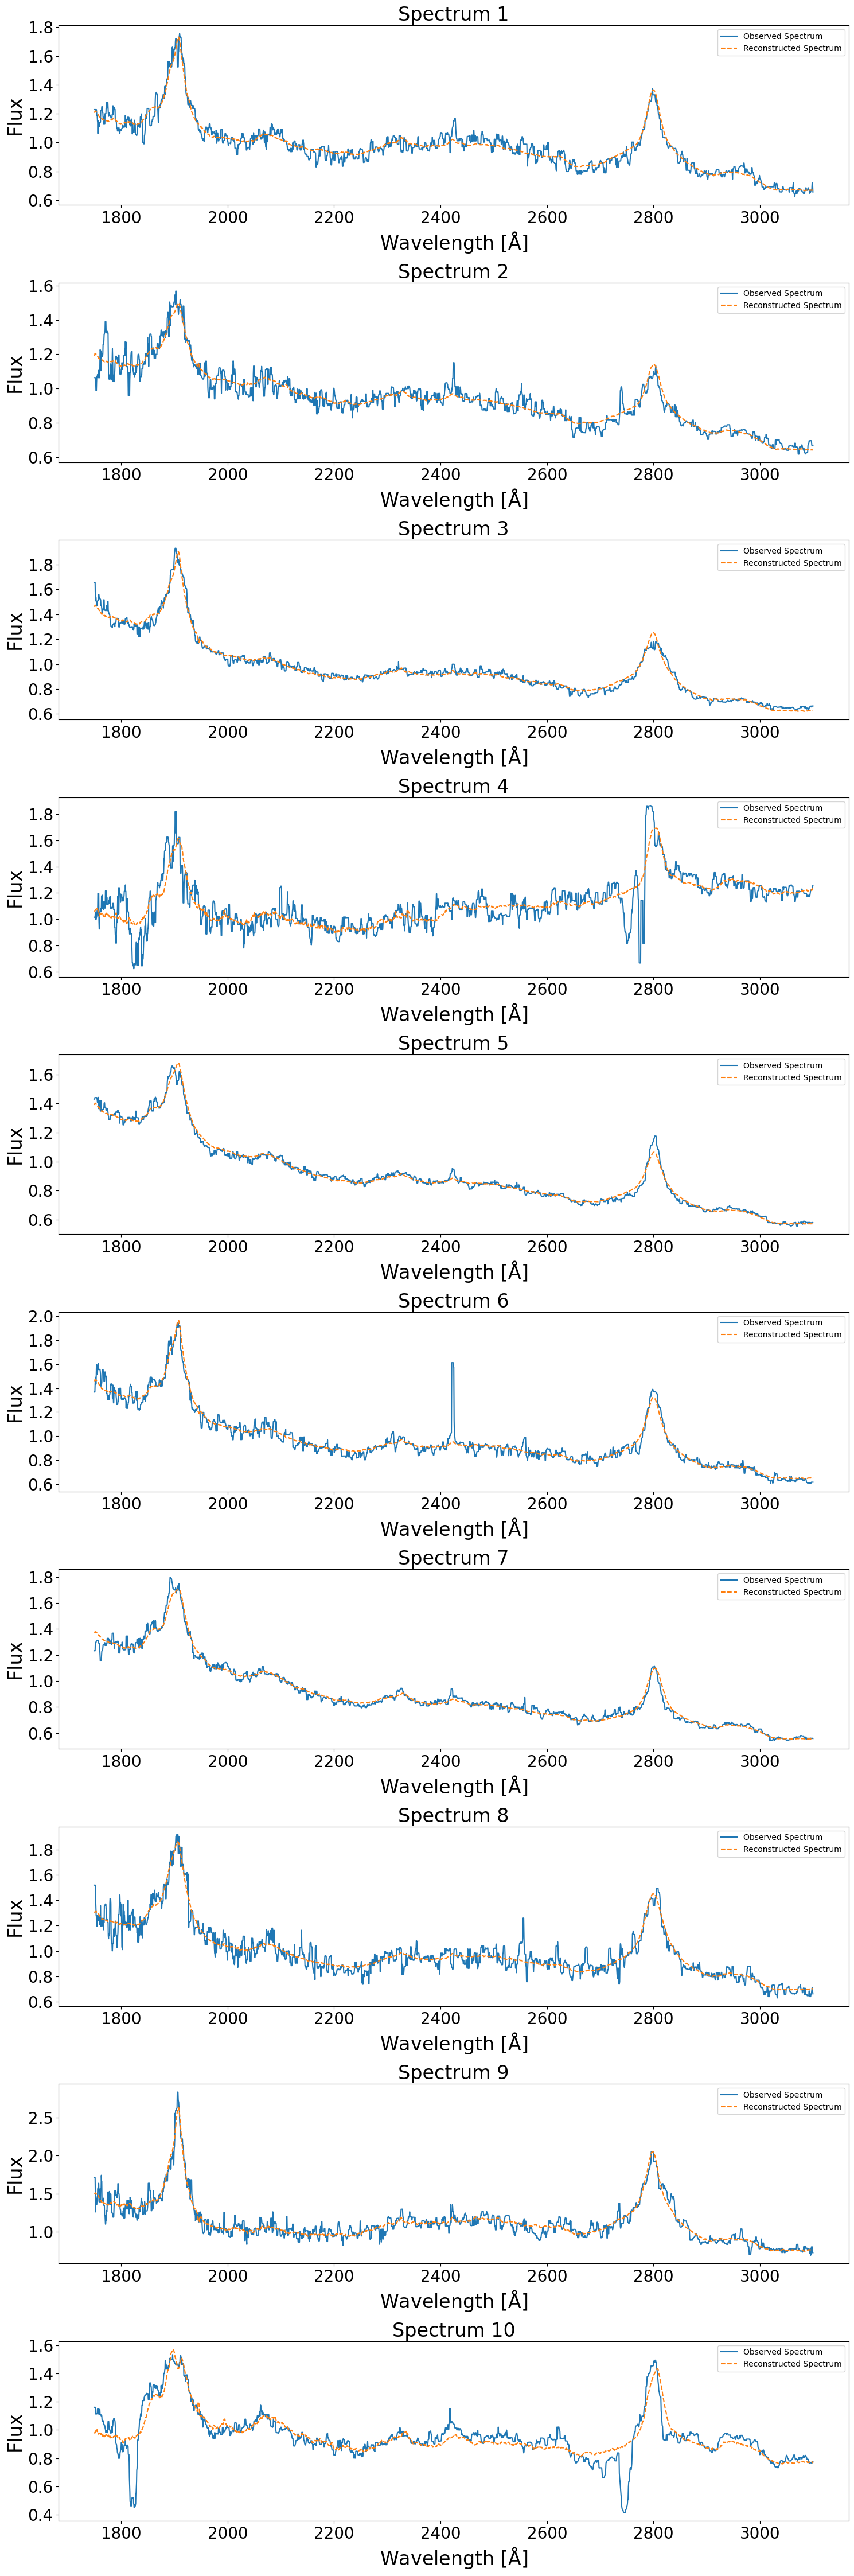

In [70]:

### 3. Please use the NMF eigenspectra to reconstruct the observed quasar spectra and plot the first 10 observed quasar spectra (i_object<10) and the reconstructed spectra. (15 points)

# Reconstruct the spectra using the NMF components
coeff = nmf.transform(Data_matrix)

# Reconstruct the outlier spectra using PCA components and coefficients
reconstruct = np.zeros(smooth_spectra.shape)
for i_object in range(len(coeff)):
    reconstruct[i_object] = (
        coeff[i_object, 0] * nmf.components_[0] +
        coeff[i_object, 1] * nmf.components_[1] +
        coeff[i_object, 2] * nmf.components_[2] +
        coeff[i_object, 3] * nmf.components_[3] +
        coeff[i_object, 4] * nmf.components_[4] +
        coeff[i_object, 5] * nmf.components_[5] )


# Plot the first 10 observed and reconstructed spectra
plt.figure(figsize=(15, 45))
for i in range(10):
    plt.subplot(10, 1, i + 1)
    plt.plot(wavelength, Data_matrix[i], label='Observed Spectrum')
    plt.plot(wavelength, reconstruct[i], label='Reconstructed Spectrum', linestyle='--')
    plt.xlabel('Wavelength [$\\rm \\AA$]', fontsize=24)
    plt.ylabel('Flux', fontsize=24)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.legend()
    plt.title(f'Spectrum {i + 1}', fontsize=24)
plt.tight_layout()
plt.show()
